<a href="https://colab.research.google.com/github/VARU2224/Anomaly-Detection-time-/blob/main/Level_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# Data Analysis Internship - Level 2**

**Name:** Vartika Srivastava

This notebook contains my solutions for the Level 2 tasks of the Cognifyz Data Analysis Internship. I used Python along with Pandas and Matplotlib to analyze the restaurant dataset and present the findings with appropriate charts and observations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Display first 5 rows
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# Level 2 - Task 1: Restaurant Ratings

## Objective

In this task, I explored the restaurant ratings available in the dataset. I wanted to understand how ratings are distributed, identify the most common rating range, and calculate the average number of votes received by restaurants.

In [3]:
# Basic statistics of restaurant ratings
df['Aggregate rating'].describe()

,Aggregate rating
count,9551.000000
mean,2.666370
std,1.516378
min,0.000000
25%,2.500000
50%,3.200000
75%,3.700000
max,4.900000


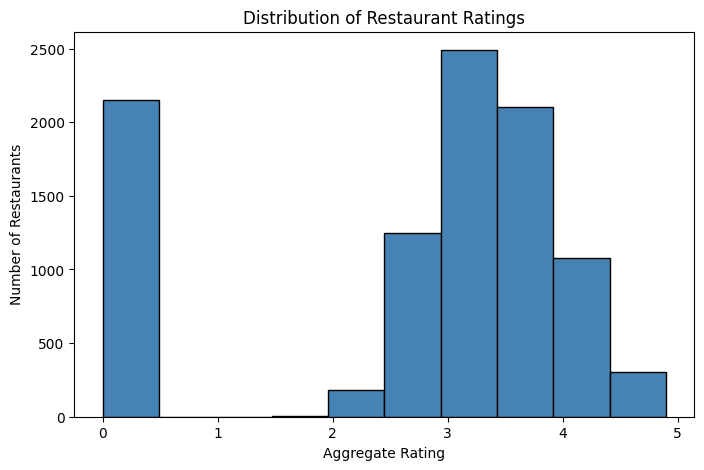

In [17]:
# Plot the distribution of restaurant ratings

plt.figure(figsize=(8,5))

plt.hist(
    df['Aggregate rating'],
    bins=10,
    color='steelblue',
    edgecolor='black')

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.show()

In [4]:
# Find the most common ratings

rating_counts = df['Aggregate rating'].value_counts().sort_index()

print(rating_counts)

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


In [6]:
# Calculate average number of votes

average_votes = df['Votes'].mean()

print("Average Votes:", round(average_votes,2))

Average Votes: 156.91


## Observation

From the analysis, I observed that most restaurants have ratings between 3.0 and 4.0, with 3.2 being one of the most common ratings. The average number of votes received by a restaurant is around 157, which shows that customer engagement varies across different restaurants. While some restaurants receive a large number of votes, many have relatively fewer customer reviews.

## Conclusion

This task helped me understand the overall distribution of restaurant ratings and customer voting patterns. I learned how to summarize numerical data and create a histogram to visualize the ratings. The analysis showed that most restaurants have moderate to good ratings, while the number of customer votes differs from one restaurant to another.

# Level 2 - Task 2: Cuisine Combination Analysis

## Objective

In this task, I explored the different cuisine combinations available in the dataset. I identified the most common cuisine combinations and compared their average ratings to understand which combinations are more popular among customers.

In [7]:
# Count the most common cuisine combinations

cuisine_combo = df['Cuisines'].value_counts()

print("Top 10 Cuisine Combinations:")
print(cuisine_combo.head(10))

Top 10 Cuisine Combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [19]:
# Count how many restaurants belong to each cuisine combination
cuisine_count = df['Cuisines'].value_counts()

# Keep only cuisine combinations that appear at least 5 times
valid_cuisines = cuisine_count[cuisine_count >= 5].index

filtered_df = df[df['Cuisines'].isin(valid_cuisines)]

# Calculate average rating
cuisine_rating = (
    filtered_df.groupby('Cuisines')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Cuisine Combinations (Minimum 5 Restaurants):")
print(cuisine_rating.head(10))

Top 10 Cuisine Combinations (Minimum 5 Restaurants):
Cuisines
North Indian, European, Mediterranean    4.460000
Burger                                   4.450000
Modern Indian                            4.345455
Indian                                   4.250000
International                            4.233333
Italian, Pizza, Sandwich                 4.220000
French                                   4.185714
Steak                                    4.185714
Cafe, Bakery, Desserts                   4.166667
Cafe, Italian, Continental               4.150000
Name: Aggregate rating, dtype: float64


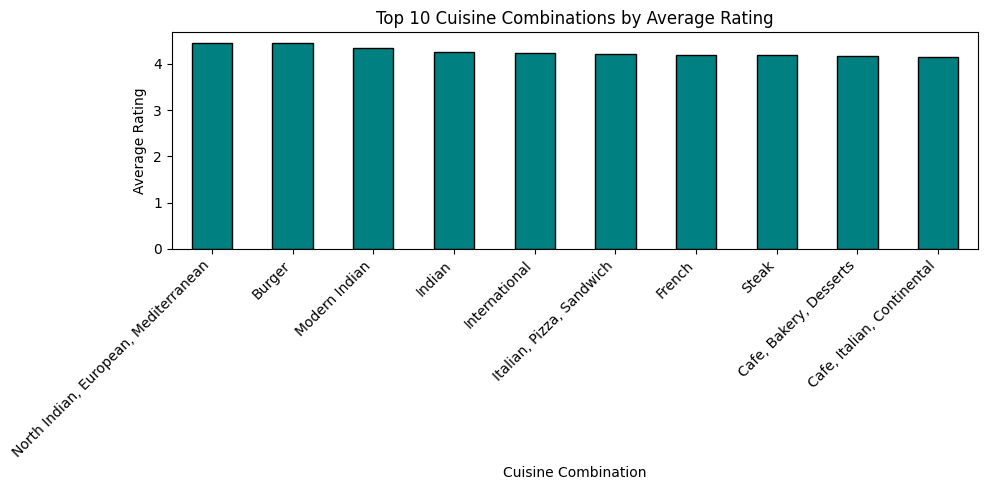

In [20]:
# Plot the top 10 cuisine combinations by average rating
top_rating = cuisine_rating.head(10)

plt.figure(figsize=(10,5))

top_rating.plot(
    kind='bar',
    color='teal',
    edgecolor='black'
)

plt.title("Top 10 Cuisine Combinations by Average Rating")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Observation

After filtering cuisine combinations that appear at least five times, I found that **North Indian, European, Mediterranean** has the highest average rating (4.46). Burger and Modern Indian cuisines also received high average ratings. This suggests that some cuisine combinations are consistently well-rated by customers rather than achieving a high rating from only a single restaurant.

## Conclusion

This task helped me compare different cuisine combinations based on their average ratings. By considering only cuisine combinations with at least five restaurants, the results became more reliable. I learned that using both frequency and average ratings provides a better understanding of customer preferences.

# Level 2 - Task 3: Geographic Analysis

## Objective

In this task, I explored the geographical information available in the dataset. I used the latitude and longitude values to understand where restaurants are located and created a simple visualization to observe their distribution.

In [22]:
# Display latitude and longitude columns

print(df[['Latitude', 'Longitude']].head())

    Latitude   Longitude
0  14.565443  121.027535
1  14.553708  121.014101
2  14.581404  121.056831
3  14.585318  121.056475
4  14.584450  121.057508


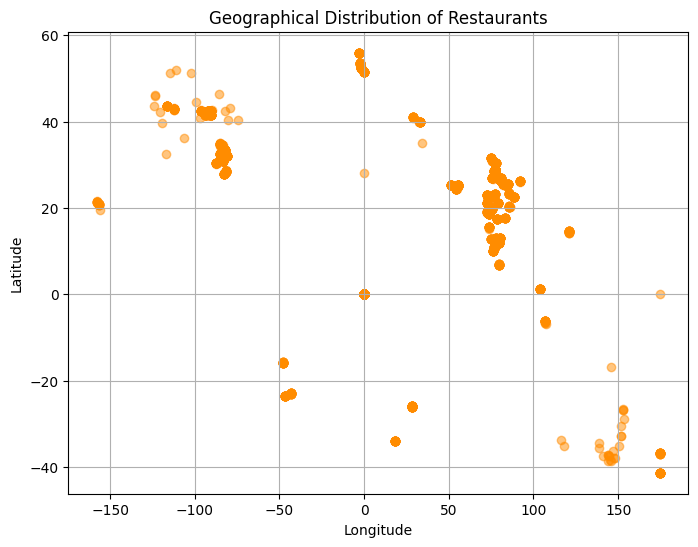

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    color='darkorange',
    alpha=0.5
)

plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)

plt.show()

## Observation

From the scatter plot, I observed that restaurants are spread across different geographical locations. Some regions have a higher concentration of restaurants, while others have fewer. This indicates that restaurant distribution is not uniform across all locations.

## Conclusion

This task helped me understand how geographical coordinates can be used to visualize restaurant locations. The scatter plot made it easier to identify areas with higher restaurant density and showed how location data can support geographical analysis.

# Level 2 - Task 4: Restaurant Chains

## Objective

In this task, I identified restaurant chains by finding restaurant names that appear multiple times in the dataset. I also analyzed which chains have the highest number of outlets and compared their average customer ratings.

In [24]:
# Count how many times each restaurant name appears
restaurant_counts = df['Restaurant Name'].value_counts()

# Keep only restaurant chains (more than one outlet)
chains = restaurant_counts[restaurant_counts > 1]

print("Top 10 Restaurant Chains:")
print(chains.head(10))

Top 10 Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [25]:
# Select only restaurants that belong to chains
chain_data = df[df['Restaurant Name'].isin(chains.index)]

# Calculate average rating
chain_ratings = (
    chain_data.groupby('Restaurant Name')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Restaurant Chains by Average Rating:")
print(chain_ratings.head(10))

Top 10 Restaurant Chains by Average Rating:
Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Garota de Ipanema            4.600
Dishoom                      4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


In [27]:
# Chains with at least 5 outlets
popular_chains = chains[chains >= 5].index

popular_chain_data = df[df['Restaurant Name'].isin(popular_chains)]

popular_chain_ratings = (
    popular_chain_data.groupby('Restaurant Name')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

print("Highest Rated Restaurant Chains (Minimum 5 Outlets):")
print(popular_chain_ratings.head(10))

Highest Rated Restaurant Chains (Minimum 5 Outlets):
Restaurant Name
Chili's            4.580000
Farzi Cafe         4.366667
Barbeque Nation    4.353846
Punjab Grill       4.340000
Mocha              4.185714
Texas Roadhouse    3.860000
Happy Hakka        3.860000
TGI Friday's       3.850000
L'Opera            3.820000
Starbucks          3.805556
Name: Aggregate rating, dtype: float64


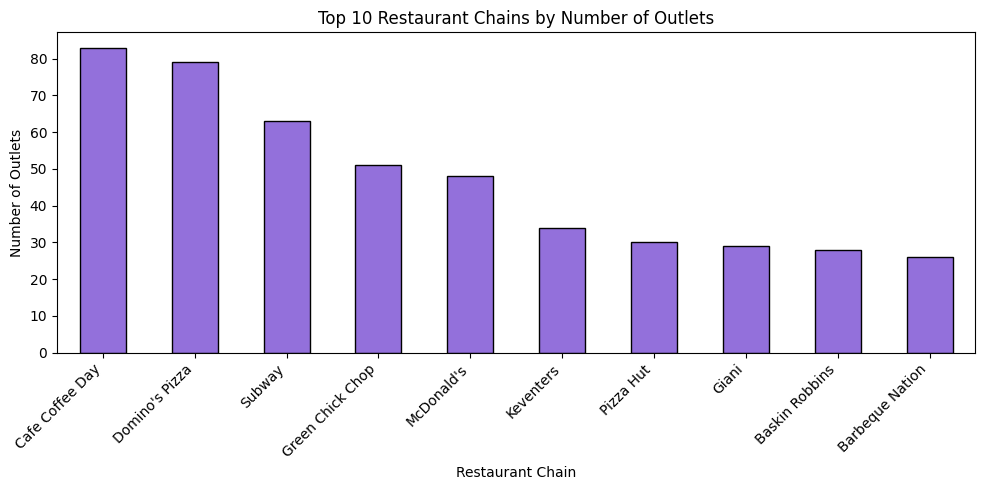

In [26]:
# Top 10 restaurant chains by number of outlets
top_chains = chains.head(10)

plt.figure(figsize=(10,5))

top_chains.plot(
    kind='bar',
    color='mediumpurple',
    edgecolor='black'
)

plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

## Observation

I found that some restaurant chains have many outlets, showing their strong presence in different locations. After considering only chains with at least five outlets, I observed that some chains consistently maintain high customer ratings. This suggests that popular restaurant chains can also provide good quality and customer satisfaction.

## Conclusion

This task helped me identify restaurant chains and compare their performance using customer ratings. I learned how to group and analyze repeated restaurant names in a dataset. Combining outlet count with average ratings provides a better understanding of the overall performance of restaurant chains.